# Homework 5: Data visualisation with Python

**Dataset:** medieval castles in Estonia (13th-16th century), the same dataset as in Homework 4. It has 36 castles with their category (Order, Bishop or Vassal castle), territorial lord, county, year of first written mention and state of preservation today.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Homework4_Altermann - Data.csv")

cat_colors = {"Order castle": "#4C72B0", "Bishop castle": "#C44E52", "Vassal castle": "#55A868"}
pres_colors = {"Preserved": "#2A9D8F", "Ruins": "#E9C46A", "Destroyed": "#8D99AE"}

print(df.shape)
df.head()

(36, 7)


,Name,Category,Territory (lord),County,First mention (year),Preservation today,Century
0,Viljandi ordulinnus,Order castle,Livonian Order,Viljandi,1224,Ruins,13th c.
1,Toompea (Tallinn) ordulinnus,Order castle,Livonian Order,Harju,1227,Preserved,13th c.
2,Karksi ordulinnus,Order castle,Livonian Order,Viljandi,1248,Ruins,13th c.
3,Rakvere ordulinnus,Order castle,Livonian Order,Lääne-Viru,1252,Ruins,13th c.
4,Narva Hermanni linnus,Order castle,Livonian Order,Ida-Viru,1256,Preserved,13th c.


## Chart 1: Number of castles by category

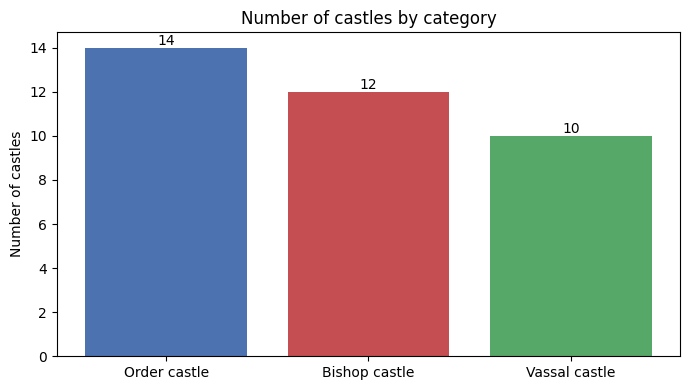

In [2]:
counts = df["Category"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=[cat_colors[c] for c in counts.index])
ax.bar_label(bars)
ax.set_title("Number of castles by category")
ax.set_ylabel("Number of castles")
plt.tight_layout()
plt.show()

**Interpretation:** The Livonian Order owned the most castles (14), followed by the bishops (12) and their vassals (10). The difference is small, so control over fortified places was split fairly evenly between the three groups. Still, the Order, as the main military power in Livonia, had the largest network of castles.

## Chart 2: When were the castles first mentioned?

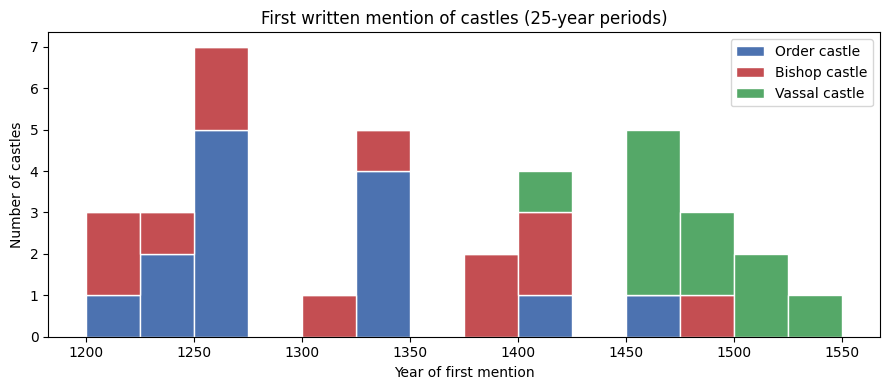

In [3]:
cats = list(cat_colors)
years = [df.loc[df["Category"] == c, "First mention (year)"] for c in cats]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(years, bins=range(1200, 1551, 25), stacked=True, label=cats,
        color=[cat_colors[c] for c in cats], edgecolor="white")
ax.set_title("First written mention of castles (25-year periods)")
ax.set_xlabel("Year of first mention")
ax.set_ylabel("Number of castles")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Castle building came in two waves. The first wave was in the 13th century (13 castles), right after the conquest, when the Order and the bishops secured their new lands. After a quieter 14th century (8 castles), a second wave followed in the 15th century (13 castles). This second wave is mostly vassal castles: no vassal castle in the dataset is mentioned before 1413. Only 2 castles appear in the 16th century, both of them vassal castles.

## Chart 3: First mention year by castle category

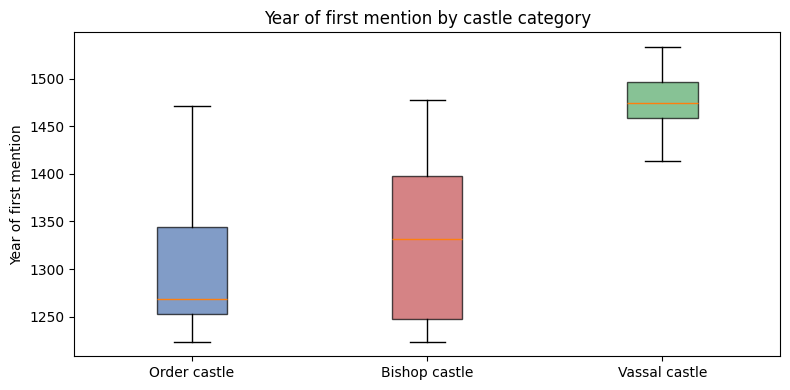

,min,median,max
Category,,,
Bishop castle,1224,1332.0,1477
Order castle,1224,1268.5,1471
Vassal castle,1413,1474.0,1533


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(years, labels=cats, patch_artist=True)
for patch, c in zip(bp["boxes"], cats):
    patch.set_facecolor(cat_colors[c])
    patch.set_alpha(0.7)
ax.set_title("Year of first mention by castle category")
ax.set_ylabel("Year of first mention")
plt.tight_layout()
plt.show()

df.groupby("Category")["First mention (year)"].agg(["min", "median", "max"])

**Interpretation:** The box plot shows a clear order in time. Order castles are the oldest (median first mention about 1268), bishop castles come next (median 1332) and vassal castles are clearly the youngest (median 1474, all between 1413 and 1533). Order and bishop castles both span almost the whole period (from 1224 to the 1470s), so the Order and the bishops kept building for a long time, while the vassals only built their own castles in the late Middle Ages.

## Chart 4: State of preservation today by category

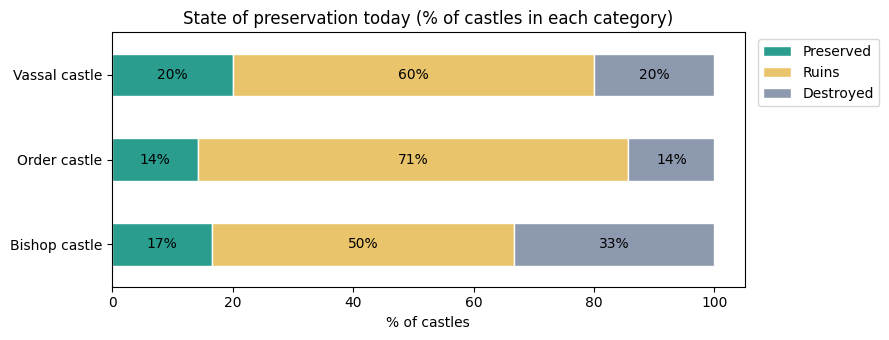

Preservation today
Ruins        22
Destroyed     8
Preserved     6
Name: count, dtype: int64

In [5]:
pres = pd.crosstab(df["Category"], df["Preservation today"], normalize="index") * 100
pres = pres[list(pres_colors)]

ax = pres.plot(kind="barh", stacked=True, figsize=(9, 3.5),
               color=[pres_colors[p] for p in pres.columns], edgecolor="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center")
ax.set_title("State of preservation today (% of castles in each category)")
ax.set_xlabel("% of castles")
ax.set_ylabel("")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

df["Preservation today"].value_counts()

**Interpretation:** Most castles survive only as ruins (22 of 36, 61%). Just 6 castles (17%) are preserved and 8 (22%) are completely destroyed. Order castles most often survive as ruins (71%), which fits their large stone construction. Bishop castles have the highest share of fully destroyed sites (33%). Every category has exactly 2 preserved castles, so the preserved share is highest for vassal castles (20%) only because there are fewer of them.

## Chart 5: Castles by county

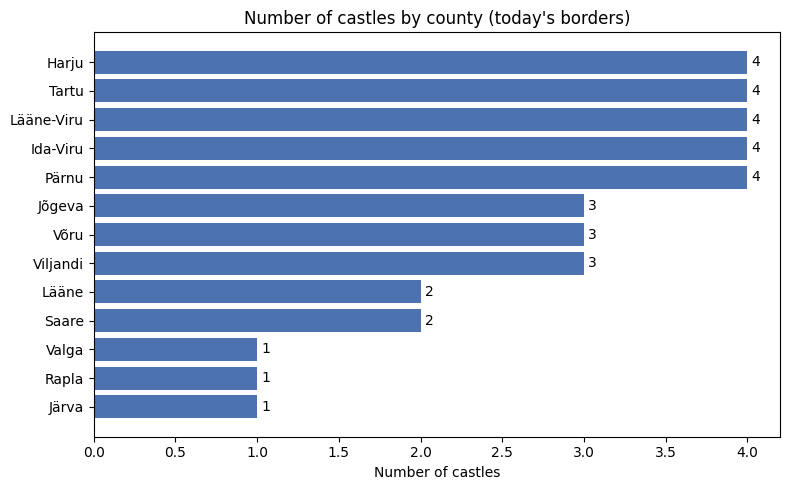

In [6]:
county = df["County"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(county.index, county.values, color="#4C72B0")
ax.bar_label(bars, padding=3)
ax.set_title("Number of castles by county (today's borders)")
ax.set_xlabel("Number of castles")
plt.tight_layout()
plt.show()

**Interpretation:** The castles are spread over almost the whole of Estonia: 13 counties have at least one castle in the dataset, and only Hiiu and Põlva counties have none. No single county dominates. Harju, Ida-Viru, Lääne-Viru, Tartu and Pärnu counties have 4 castles each, while Järva, Valga and Rapla have only one. This even spread shows that the castle network covered the whole territory, not just one region.

## Conclusion

The charts show that castle building in medieval Estonia was shared between the Order, the bishops and the vassals, and that it happened in two waves: the 13th-century conquest castles of the Order and bishops and the 15th-century vassal castles. Castles were built across the whole country, but most of them survive today only as ruins.